# Plot results

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

In [29]:
def plot_latency_data(csv_file):
    # Load the CSV data
    df = pd.read_csv(csv_file)
    
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # --- Plot 1: Time-Series Scatter ---
    # Plotting every 10th point if the dataset is massive, to save memory
    step = 1 if len(df) < 10000 else len(df) // 10000 
    ax1.scatter(df['Cycle'][::step], df['Act_us'][::step], alpha=0.5, color='blue', s=2)
    ax1.plot(df['Cycle'], df['Max_us'], color='red', label='Max Latency', linewidth=1.5)
    
    ax1.set_title('Wakeup Latency Over Time')
    ax1.set_xlabel('Cycle Count')
    ax1.set_ylabel('Latency (microseconds)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 2: Logarithmic Histogram ---
    bins = range(0, df['Act_us'].max() + 10, 2)
    ax2.hist(df['Act_us'], bins=bins, log=True, color='purple', edgecolor='black', alpha=0.7)
    
    ax2.set_title('Latency Distribution (Log Scale)')
    ax2.set_xlabel('Actual Latency (microseconds)')
    ax2.set_ylabel('Frequency (Log Scale)')
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    
    # Save to a high-res image for your research paper/report
    output_png = csv_file.replace('.csv', '_plot.png')
    plt.savefig(output_png, dpi=300)
    print(f"Plots saved successfully to {output_png}")
    
    # Display the plot window
    plt.show()

Plots saved successfully to ./results/baseline_plot.png


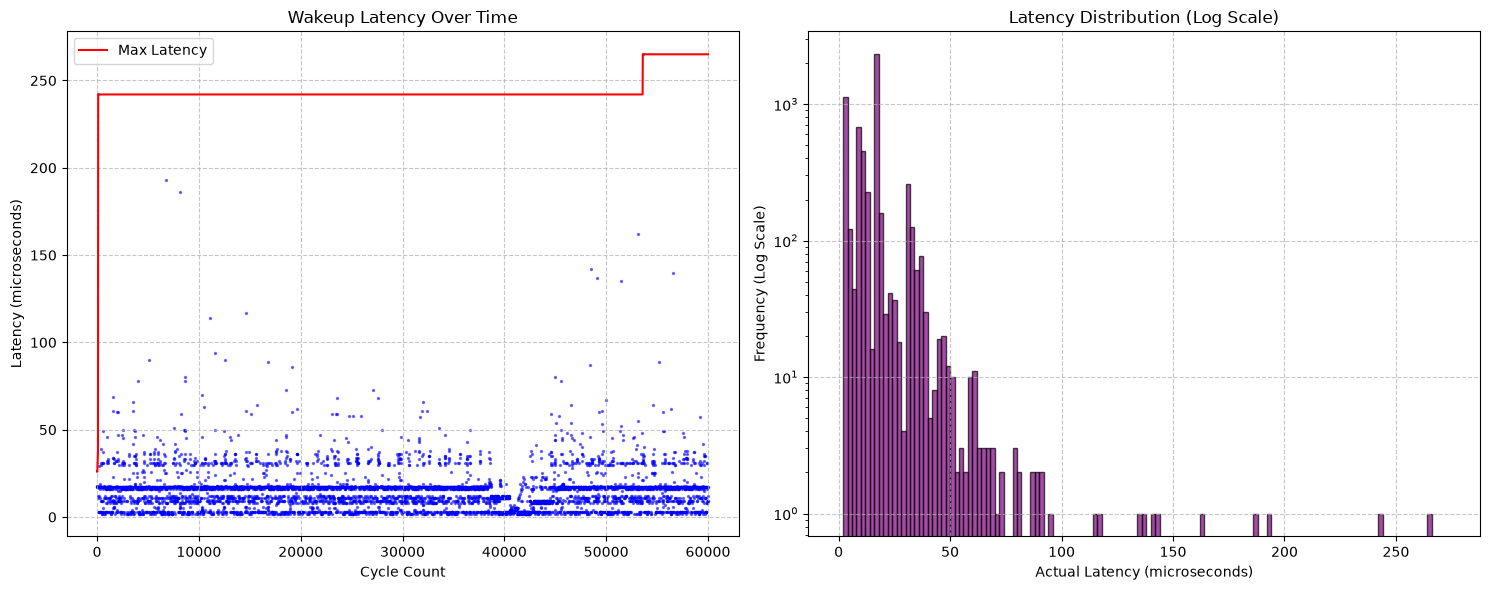

In [30]:
file_name = "baseline"

plot_latency_data(f"./results/{file_name}.csv")